# Predicción de Deporte Olímpico por Perfil Físico (Machine Learning)

Este notebook es la continuación del análisis exploratorio del proyecto
[120 Years of Olympic History](athlete_events.ipynb).

Partiendo del hallazgo de que cada deporte tiene un perfil físico
diferenciado, construimos un modelo que predice qué deporte practica
un atleta en función de su edad, altura, peso y sexo.



## 1. Objetivos

- Construir un modelo de clasificación multiclase que prediga el deporte
  olímpico de un atleta a partir de su perfil físico
- Identificar qué variables físicas (edad, altura, peso, sexo) tienen
  mayor poder predictivo
- Comparar el rendimiento de varios modelos de ML
- Crear una función interactiva que prediga los 3 deportes más probables
  para cualquier perfil físico introducido

## 2. Hipótesis

- **H1** : El peso y la altura serán las variables más predictivas,
  por encima de la edad y el sexo
- **H2** : Los deportes con perfiles físicos extremos (gimnasia, halterofilia)
  serán los más fáciles de predecir
- **H3** : Deportes similares (natación y waterpolo, atletismo y triatlón)
  serán los más difíciles de distinguir para el modelo

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


import warnings
warnings.filterwarnings("ignore")

## 3. Carga y preparación de datos

In [2]:
df = pd.read_csv("athlete_events.csv")
print(f"Filas totales: {len(df)}")
df.head()

Filas totales: 271116


,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN


In [3]:
# Seleccionamos solo las columnas relevantes para el modelo
df_ml = df[["Age", "Height", "Weight", "Sex", "Sport"]].copy()

print(f"Filas antes de eliminar nulos: {len(df_ml)}")
df_ml = df_ml.dropna()
print(f"Filas después de eliminar nulos: {len(df_ml)}")
print(f"Deportes únicos: {df_ml['Sport'].nunique()}")

Filas antes de eliminar nulos: 271116
Filas después de eliminar nulos: 206165
Deportes únicos: 56


In [4]:
# Mantenemos solo deportes con al menos 500 atletas
# Si no, el modelo tiene clases con muy pocos ejemplos y no aprende
conteo_deportes = df_ml["Sport"].value_counts()
deportes_validos = conteo_deportes[conteo_deportes >= 500].index

df_ml = df_ml[df_ml["Sport"].isin(deportes_validos)]

print(f"Deportes tras filtro: {df_ml['Sport'].nunique()}")
print(f"Filas tras filtro: {len(df_ml)}")
conteo_deportes[conteo_deportes >= 500].head(10)

Deportes tras filtro: 45
Filas tras filtro: 204505


Sport
Athletics               32374
Swimming                18776
Gymnastics              18271
Rowing                   7790
Cycling                  7775
Cross Country Skiing     7529
Shooting                 7260
Fencing                  6537
Alpine Skiing            6322
Canoeing                 5550
Name: count, dtype: int64

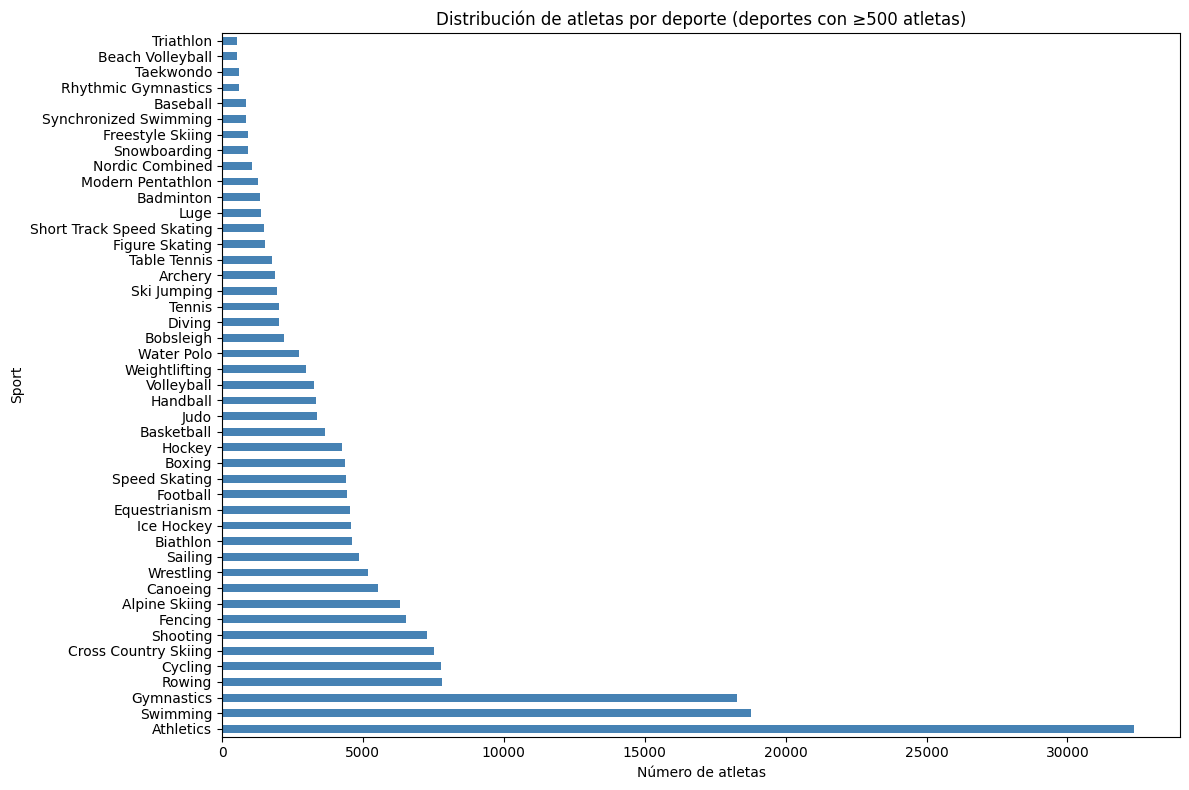


Deporte más frecuente: Athletics (32,374 atletas)
Deporte menos frecuente: Triathlon (526 atletas)


In [5]:
# Encoding de sexo: M=1, F=0
df_ml["Sex"] = (df_ml["Sex"] == "M").astype(int)

# Análisis de desbalanceo
plt.figure(figsize=(12, 8))
df_ml["Sport"].value_counts().plot(kind="barh", color="steelblue")
plt.xlabel("Número de atletas")
plt.title("Distribución de atletas por deporte (deportes con ≥500 atletas)")
plt.tight_layout()
plt.show()

print(f"\nDeporte más frecuente: {df_ml['Sport'].value_counts().index[0]} "
      f"({df_ml['Sport'].value_counts().iloc[0]:,} atletas)")
print(f"Deporte menos frecuente: {df_ml['Sport'].value_counts().index[-1]} "
      f"({df_ml['Sport'].value_counts().iloc[-1]:,} atletas)")

In [6]:
from sklearn.model_selection import train_test_split

X = df_ml[["Age", "Height", "Weight", "Sex"]]
y = df_ml["Sport"]

# Primera división: 60% train, 40% temporal
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.4,
    random_state=42,
    stratify=y
)

# Segunda división: 50% del temporal = 20% validation, 20% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

print(f"Train:      {len(X_train):,} filas ({len(X_train)/len(X)*100:.0f}%)")
print(f"Validation: {len(X_val):,} filas ({len(X_val)/len(X)*100:.0f}%)")
print(f"Test:       {len(X_test):,} filas ({len(X_test)/len(X)*100:.0f}%)")

Train:      122,703 filas (60%)
Validation: 40,901 filas (20%)
Test:       40,901 filas (20%)


Los datos están listos para el modelado. Tenemos:
- **Features**: edad, altura, peso y sexo
- **Variable objetivo**: deporte (clasificación multiclase)
- **Train/test split**: 80/20 con estratificación por clase
- `class_weight='balanced'` en todos los modelos para compensar
  el desbalanceo entre deportes

### Selección de modelos

Para este problema de clasificación multiclase con clases desbalanceadas
hemos seleccionado Logistic Regression y Random Forest como modelos
a comparar. Ambos permiten compensar el desbalanceo entre categorías de
forma nativa mediante el parámetro `class_weight='balanced'`, que ajusta
automáticamente el peso de cada clase en proporción inversa a su frecuencia
en el dataset.

Modelos como Gradient Boosting o XGBoost, aunque potencialmente más
precisos, no soportan `class_weight` directamente — requieren calcular
y asignar manualmente `sample_weight` para cada observación, lo que
añade complejidad al pipeline sin garantizar una mejora significativa
para este caso concreto.

La Logistic Regression actúa como baseline interpretable: al ser un
modelo lineal, establece el mínimo rendimiento esperable y nos permite
cuantificar cuánto aporta la no linealidad del Random Forest.
El Random Forest es el modelo principal: robusto frente al desbalanceo,
resistente al ruido y capaz de capturar relaciones no lineales entre
las variables físicas y las categorías deportivas.

## 4. Modelado

Entrenaremos tres modelos en orden de complejidad creciente,
evaluando cada uno sobre el conjunto de validación.
Solo el modelo ganador se evaluará sobre el conjunto de test al final.

| Modelo | Complejidad | Ventaja |
|---|---|---|
| Logistic Regression | Baja | Baseline interpretable |
| Random Forest | Media | Robusto, feature importance |

### 4.1 Baseline — Logistic Regression

In [7]:
# Logistic Regression necesita escalado de features
lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ))
])

lr_pipeline.fit(X_train, y_train)
pred_lr_val = lr_pipeline.predict(X_val)

acc_lr = accuracy_score(y_val, pred_lr_val)
f1_lr = f1_score(y_val, pred_lr_val, average="macro")

print(f"Logistic Regression — Validación")
print(f"Accuracy: {acc_lr:.3f}")
print(f"F1 Macro: {f1_lr:.3f}")

Logistic Regression — Validación
Accuracy: 0.141
F1 Macro: 0.090


La Logistic Regression nos sirve como baseline. Al ser un modelo lineal,
esperamos que tenga dificultades con la separación entre deportes
con perfiles físicos similares. El F1 Macro es la métrica principal
porque penaliza igual los errores en deportes frecuentes y poco frecuentes.

### 4.2 Random Forest

In [8]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1  # usa todos los núcleos disponibles
)

rf_model.fit(X_train, y_train)
pred_rf_val = rf_model.predict(X_val)

acc_rf = accuracy_score(y_val, pred_rf_val)
f1_rf = f1_score(y_val, pred_rf_val, average="macro")

print(f"Random Forest — Validación")
print(f"Accuracy: {acc_rf:.3f}")
print(f"F1 Macro: {f1_rf:.3f}")

Random Forest — Validación
Accuracy: 0.240
F1 Macro: 0.175


### 4.4 Comparativa de modelos

In [9]:
resultados = pd.DataFrame({
    "Modelo": ["Logistic Regression", "Random Forest"],
    "Accuracy (Val)": [acc_lr, acc_rf],
    "F1 Macro (Val)": [f1_lr, f1_rf]
}).sort_values("F1 Macro (Val)", ascending=False)

resultados = resultados.round(3)
resultados

,Modelo,Accuracy (Val),F1 Macro (Val)
1,Random Forest,0.240,0.175
0,Logistic Regression,0.141,0.090


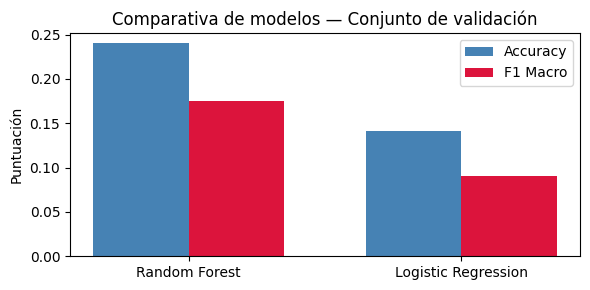

In [10]:
# Filtrar solo los modelos de Regresión Logística y Random Forest
resultados_compare = resultados[resultados["Modelo"].isin(["Logistic Regression", "Random Forest"])].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(6, 3))

x = range(len(resultados_compare))
bars1 = ax.bar(x, resultados_compare["Accuracy (Val)"],
               width=0.35, label="Accuracy", color="steelblue")
bars2 = ax.bar([i + 0.35 for i in x], resultados_compare["F1 Macro (Val)"],
               width=0.35, label="F1 Macro", color="crimson")

ax.set_xticks([i + 0.175 for i in x])
ax.set_xticklabels(resultados_compare["Modelo"])
ax.set_ylabel("Puntuación")
ax.set_title("Comparativa de modelos — Conjunto de validación")
ax.legend()
plt.tight_layout()
plt.show()

## 4.5 Ajustes del modelo

Nos quedaremos con el modelo Random Forest ya que es el que mayor desempeño obtenemos. Nos damos cuenta de que al modelo se le dificulta mucho obtener el deporte exacto cuando hay un total de 56 deportes los cuales muchos requieren características físicas muy parecidas.
Ponemos el ejemplo de un deportista con un cuerpo adaptado a la actividad cardiovascular y esfuerzo prolongado alto,

In [11]:
print(df_ml['Sport'].nunique())

45


In [12]:
df_ml['Sport'].unique()

array(['Basketball', 'Judo', 'Speed Skating', 'Cross Country Skiing',
       'Ice Hockey', 'Badminton', 'Sailing', 'Biathlon', 'Gymnastics',
       'Athletics', 'Alpine Skiing', 'Weightlifting', 'Wrestling', 'Luge',
       'Rowing', 'Bobsleigh', 'Swimming', 'Football', 'Equestrianism',
       'Shooting', 'Taekwondo', 'Boxing', 'Fencing', 'Diving', 'Canoeing',
       'Handball', 'Water Polo', 'Tennis', 'Cycling', 'Hockey',
       'Figure Skating', 'Archery', 'Volleyball', 'Synchronized Swimming',
       'Modern Pentathlon', 'Table Tennis', 'Nordic Combined', 'Baseball',
       'Rhythmic Gymnastics', 'Freestyle Skiing', 'Beach Volleyball',
       'Triathlon', 'Ski Jumping', 'Snowboarding',
       'Short Track Speed Skating'], dtype=object)

In [13]:
# Feature engineering: añadimos IMC
df_ml["IMC"] = df_ml["Weight"] / ((df_ml["Height"] / 100) ** 2)

# Actualizamos features
X = df_ml[["Age", "Height", "Weight", "Sex", "IMC"]]
y = df_ml["Sport"]

In [14]:
grupos_deporte = {
    # RESISTENCIA
    "Athletics": "Resistencia",           # maratón, marcha
    "Cycling": "Resistencia",
    "Rowing": "Resistencia",
    "Swimming": "Resistencia",
    "Triathlon": "Resistencia",
    "Canoeing": "Resistencia",
    "Cross Country Skiing": "Resistencia",
    "Biathlon": "Resistencia",
    "Nordic Combined": "Resistencia",
    "Modern Pentathlon": "Resistencia",

    # FUERZA Y POTENCIA
    "Weightlifting": "Fuerza y Potencia",
    "Wrestling": "Fuerza y Potencia",
    "Boxing": "Fuerza y Potencia",
    "Judo": "Fuerza y Potencia",
    "Taekwondo": "Fuerza y Potencia",
    "Bobsleigh": "Fuerza y Potencia",

    # VELOCIDAD Y EXPLOSIVIDAD
    "Short Track Speed Skating": "Velocidad y Explosividad",
    "Speed Skating": "Velocidad y Explosividad",
    "Alpine Skiing": "Velocidad y Explosividad",
    "Freestyle Skiing": "Velocidad y Explosividad",
    "Snowboarding": "Velocidad y Explosividad",
    "Ski Jumping": "Velocidad y Explosividad",
    "Luge": "Velocidad y Explosividad",

    # COORDINACIÓN, TÉCNICA Y FLEXIBILIDAD
    "Gymnastics": "Coordinacion Tecnica Flexibilidad",
    "Rhythmic Gymnastics": "Coordinacion Tecnica Flexibilidad",
    "Diving": "Coordinacion Tecnica Flexibilidad",
    "Synchronized Swimming": "Coordinacion Tecnica Flexibilidad",
    "Figure Skating": "Coordinacion Tecnica Flexibilidad",

    # PRECISIÓN Y CONTROL
    "Shooting": "Precision y Control",
    "Archery": "Precision y Control",
    "Fencing": "Precision y Control",

    # DEPORTES DE EQUIPO
    "Basketball": "Deportes de Equipo",
    "Football": "Deportes de Equipo",
    "Volleyball": "Deportes de Equipo",
    "Hockey": "Deportes de Equipo",
    "Water Polo": "Deportes de Equipo",
    "Baseball": "Deportes de Equipo",
    "Beach Volleyball": "Deportes de Equipo",
    "Ice Hockey": "Deportes de Equipo",
    "Handball": "Deportes de Equipo",

    # TÉCNICO-ESTRATÉGICOS CON FACTORES EXTERNOS
    "Sailing": "Tecnico Estrategico",
    "Equestrianism": "Tecnico Estrategico",
    "Badminton": "Tecnico Estrategico",
    "Tennis": "Tecnico Estrategico",
    "Table Tennis": "Tecnico Estrategico",
}

In [15]:
df_ml["Grupo"] = df_ml["Sport"].map(grupos_deporte)

X = df_ml[["Age", "Height", "Weight", "Sex", "IMC"]]
y = df_ml["Grupo"]

In [16]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

In [17]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1  # usa todos los núcleos disponibles
)

rf_model.fit(X_train, y_train)
pred_rf_val = rf_model.predict(X_val)

acc_rf = accuracy_score(y_val, pred_rf_val)
f1_rf = f1_score(y_val, pred_rf_val, average="macro")

print(f"Random Forest — Validación")
print(f"Accuracy: {acc_rf:.3f}")
print(f"F1 Macro: {f1_rf:.3f}")

Random Forest — Validación
Accuracy: 0.438
F1 Macro: 0.402


In [18]:
pred_train = rf_model.predict(X_train)
pred_val = rf_model.predict(X_val)

f1_train = f1_score(y_train, pred_train, average="macro")
f1_val = f1_score(y_val, pred_val, average="macro")

print(f"F1 Macro en Train:      {f1_train:.3f}")
print(f"F1 Macro en Validación: {f1_val:.3f}")
print(f"Diferencia:             {f1_train - f1_val:.3f}")

F1 Macro en Train:      0.604
F1 Macro en Validación: 0.402
Diferencia:             0.202



Una diferencia de 0.202 indica que el modelo memorizaba los datos de
entrenamiento sin generalizar correctamente. Para corregirlo limitamos
la complejidad del modelo ajustando los siguientes hiperparámetros:

- `max_depth=10` — limita la profundidad máxima de cada árbol
- `min_samples_leaf=5` — cada hoja necesita al menos 5 ejemplos
- `min_samples_split=10` — un nodo necesita al menos 10 ejemplos para dividirse
- `max_features='sqrt'` — cada árbol usa solo la raíz cuadrada del total
  de features, introduciendo más variabilidad y reduciendo la correlación
  entre árboles

In [19]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=5,
    min_samples_split=10,
    max_features='sqrt',
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)


rf_model.fit(X_train, y_train)
pred_rf_val = rf_model.predict(X_val)

acc_rf = accuracy_score(y_val, pred_rf_val)
f1_rf = f1_score(y_val, pred_rf_val, average="macro")

print(f"Random Forest — Validación")
print(f"Accuracy: {acc_rf:.3f}")
print(f"F1 Macro: {f1_rf:.3f}")

pred_train = rf_model.predict(X_train)
pred_val = rf_model.predict(X_val)


f1_train = f1_score(y_train, pred_train, average="macro")
f1_val = f1_score(y_val, pred_val, average="macro")

print(f"F1 Macro en Train:      {f1_train:.3f}")
print(f"F1 Macro en Validación: {f1_val:.3f}")
print(f"Diferencia:             {f1_train - f1_val:.3f}")

Random Forest — Validación
Accuracy: 0.411
F1 Macro: 0.376
F1 Macro en Train:      0.394
F1 Macro en Validación: 0.376
Diferencia:             0.018


## 5. Evaluación final y visualizaciones

Una vez seleccionado el Random Forest ajustado como modelo final,
lo evaluamos sobre el conjunto de test (datos que no han sido
vistos en ningún momento del proceso de entrenamiento ni selección).

In [20]:
from sklearn.metrics import confusion_matrix

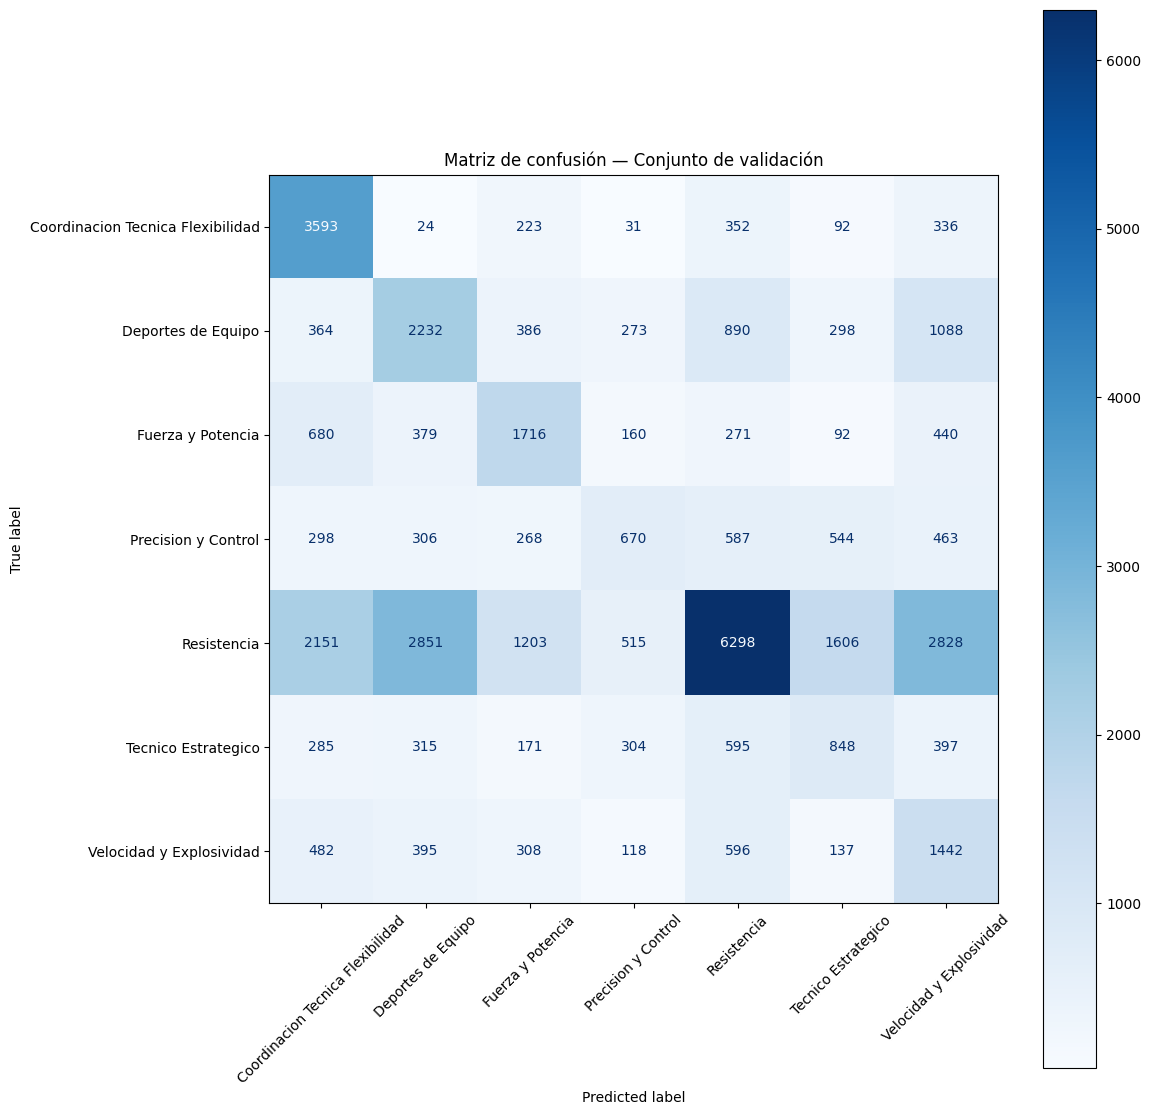

In [21]:

cm = confusion_matrix(y_val, rf_model.predict(X_val), 
                      labels=rf_model.classes_)

fig, ax = plt.subplots(figsize=(12, 12))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                               display_labels=rf_model.classes_)
disp.plot(ax=ax, colorbar=True, cmap="Blues", 
          xticks_rotation=45)
ax.set_title("Matriz de confusión — Conjunto de validación")
plt.tight_layout()
plt.show()

In [26]:
import numpy as np
import pandas as pd

# Calculamos el ratio de accuracy para cada clase:
# (predicciones correctas) / (total de muestras para esa clase)

ratios_accuracy = np.diag(cm) / cm.sum(axis=1)

tabla_accuracy = pd.DataFrame({
    'Clase': rf_model.classes_,
    'Ratio Accuracy': ratios_accuracy
})

print("Ratios de accuracy por clase (proporción de aciertos de cada clase):")
display(tabla_accuracy.round(2))

Ratios de accuracy por clase (proporción de aciertos de cada clase):


,Clase,Ratio Accuracy
0,Coordinacion Tecnica Flexibilidad,0.77
1,Deportes de Equipo,0.40
2,Fuerza y Potencia,0.45
3,Precision y Control,0.22
4,Resistencia,0.36
5,Tecnico Estrategico,0.29
6,Velocidad y Explosividad,0.40


In [22]:
# Evaluación final — solo se ejecuta una vez
pred_test = rf_model.predict(X_test)

print("=== EVALUACIÓN FINAL — CONJUNTO DE TEST ===\n")
print(f"Accuracy:       {accuracy_score(y_test, pred_test):.3f}")
print(f"F1 Macro:       {f1_score(y_test, pred_test, average='macro'):.3f}")
print()
print(classification_report(y_test, pred_test))

=== EVALUACIÓN FINAL — CONJUNTO DE TEST ===

Accuracy:       0.408
F1 Macro:       0.374

                                   precision    recall  f1-score   support

Coordinacion Tecnica Flexibilidad       0.45      0.77      0.57      4652
               Deportes de Equipo       0.34      0.40      0.37      5530
                Fuerza y Potencia       0.40      0.45      0.43      3738
              Precision y Control       0.32      0.22      0.26      3136
                      Resistencia       0.65      0.36      0.46     17452
              Tecnico Estrategico       0.24      0.29      0.26      2915
         Velocidad y Explosividad       0.20      0.40      0.27      3478

                         accuracy                           0.41     40901
                        macro avg       0.37      0.41      0.37     40901
                     weighted avg       0.47      0.41      0.41     40901



### 5.1 Feature Importance ¿Qué variable física predice más?

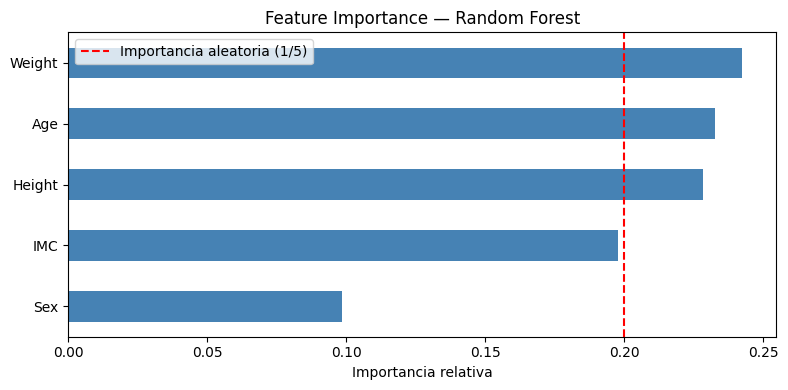


Importancia de cada variable:
  Weight: 24.3%
  Age: 23.3%
  Height: 22.8%
  IMC: 19.8%
  Sex: 9.9%


In [23]:
importancias = pd.Series(
    rf_model.feature_importances_,
    index=["Age", "Height", "Weight", "Sex", "IMC"]
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
importancias.plot(kind="barh", color="steelblue", ax=ax)
ax.set_xlabel("Importancia relativa")
ax.set_title("Feature Importance — Random Forest")
ax.axvline(x=1/5, color="red", linestyle="--", 
           label="Importancia aleatoria (1/5)")
ax.legend()
plt.tight_layout()
plt.show()

print("\nImportancia de cada variable:")
for feature, imp in importancias.sort_values(ascending=False).items():
    print(f"  {feature}: {imp*100:.1f}%")

### 5.2 Rendimiento por categoría de deporte

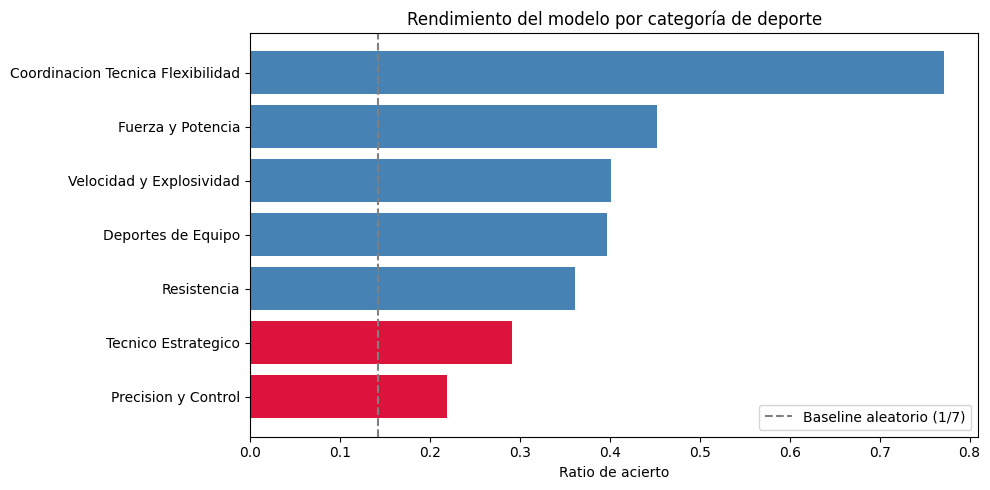

                            Grupo  Aciertos  Total  Ratio de acierto
              Precision y Control       687   3136          0.219069
              Tecnico Estrategico       851   2915          0.291938
                      Resistencia      6299  17452          0.360933
               Deportes de Equipo      2194   5530          0.396745
         Velocidad y Explosividad      1395   3478          0.401093
                Fuerza y Potencia      1690   3738          0.452113
Coordinacion Tecnica Flexibilidad      3588   4652          0.771281


In [24]:
cm = confusion_matrix(y_test, pred_test, labels=rf_model.classes_)

df_ratios = pd.DataFrame({
    "Grupo": rf_model.classes_,
    "Aciertos": cm.diagonal(),
    "Total": cm.sum(axis=1),
    "Ratio de acierto": cm.diagonal() / cm.sum(axis=1)
}).sort_values("Ratio de acierto", ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["crimson" if r < 0.3 else "steelblue" 
          for r in df_ratios["Ratio de acierto"]]
ax.barh(df_ratios["Grupo"], df_ratios["Ratio de acierto"], color=colors)
ax.axvline(x=1/7, color="gray", linestyle="--", 
           label="Baseline aleatorio (1/7)")
ax.set_xlabel("Ratio de acierto")
ax.set_title("Rendimiento del modelo por categoría de deporte")
ax.legend()
plt.tight_layout()
plt.show()

print(df_ratios.to_string(index=False))

### Interpretación de resultados

**Feature Importance:** El peso, la edad y la altura son prácticamente
igual de predictivos (~23-24% cada uno), lo que refuta parcialmente
la H1, esperábamos que peso y altura dominasen sobre la edad. El sexo
es la variable menos informativa (10%), probablemente porque la agrupación
por categorías físicas ya captura implícitamente parte de esa información.

**Rendimiento por categoría:** El modelo predice con alta fiabilidad
los deportes de Coordinación Técnica y Flexibilidad (77%) gracias a su
perfil físico extremo, atletas ligeros, jóvenes y de baja estatura.
En el extremo opuesto, Precisión y Control (22%) y Técnico Estratégico
(29%) son las categorías donde el físico menos determina el rendimiento,
confirmando la H3.

**Matriz de confusión:** Los errores más frecuentes ocurren entre
Resistencia y otras categorías, especialmente Deportes de Equipo y
Velocidad y Explosividad, grupos con perfiles físicos solapados.
Coordinación Técnica prácticamente no genera confusión con ningún
otro grupo.

## 6. Demo interactiva

Introduciendo el perfil físico de una persona, el modelo predice
las 3 categorías de deporte más probables junto con su probabilidad.

In [27]:
def predecir_categoria(edad, altura, peso, sexo):
    imc = peso / ((altura / 100) ** 2)
    
    persona = pd.DataFrame({
        "Age":    [edad],
        "Height": [altura],
        "Weight": [peso],
        "Sex":    [1 if sexo.upper() == "M" else 0],
        "IMC":    [imc]
    })
    
    probs = rf_model.predict_proba(persona)[0]
    top3 = sorted(zip(rf_model.classes_, probs),
                  key=lambda x: x[1], reverse=True)[:3]
    
    print(f"Perfil introducido:")
    print(f"  Edad:    {edad} años")
    print(f"  Altura:  {altura} cm")
    print(f"  Peso:    {peso} kg")
    print(f"  Sexo:    {'Hombre' if sexo.upper() == 'M' else 'Mujer'}")
    print(f"  IMC:     {imc:.1f}")
    print()
    print("Top 3 categorías más probables:")
    for i, (categoria, prob) in enumerate(top3, 1):
        barra = "█" * int(prob * 40)
        print(f"  {i}. {categoria:<35} {prob*100:5.1f}%  {barra}")

In [28]:
print("=" * 60)
print("EJEMPLO 1 — Perfil de gimnasta")
print("=" * 60)
predecir_categoria(edad=19, altura=158, peso=52, sexo="F")

print()
print("=" * 60)
print("EJEMPLO 2 — Perfil de halterófilo")
print("=" * 60)
predecir_categoria(edad=26, altura=170, peso=105, sexo="M")

print()
print("=" * 60)
print("EJEMPLO 3 — Perfil de jugador de baloncesto")
print("=" * 60)
predecir_categoria(edad=24, altura=200, peso=95, sexo="M")

print()
print("=" * 60)
print("EJEMPLO 4 — Tu propio perfil")
print("=" * 60)
predecir_categoria(edad=20, altura=175, peso=70, sexo="M")  # Cambia estos valores

EJEMPLO 1 — Perfil de gimnasta
Perfil introducido:
  Edad:    19 años
  Altura:  158 cm
  Peso:    52 kg
  Sexo:    Mujer
  IMC:     20.8

Top 3 categorías más probables:
  1. Coordinacion Tecnica Flexibilidad    69.3%  ███████████████████████████
  2. Velocidad y Explosividad              9.8%  ███
  3. Resistencia                           5.7%  ██

EJEMPLO 2 — Perfil de halterófilo
Perfil introducido:
  Edad:    26 años
  Altura:  170 cm
  Peso:    105 kg
  Sexo:    Hombre
  IMC:     36.3

Top 3 categorías más probables:
  1. Fuerza y Potencia                    84.2%  █████████████████████████████████
  2. Precision y Control                   8.0%  ███
  3. Resistencia                           3.4%  █

EJEMPLO 3 — Perfil de jugador de baloncesto
Perfil introducido:
  Edad:    24 años
  Altura:  200 cm
  Peso:    95 kg
  Sexo:    Hombre
  IMC:     23.8

Top 3 categorías más probables:
  1. Deportes de Equipo                   67.6%  ███████████████████████████
  2. Resistencia    

Los ejemplos confirman la intuición del modelo:
- Perfiles con bajo IMC y poca altura → Coordinación Técnica
- Perfiles con alto peso y baja altura → Fuerza y Potencia  
- Perfiles con gran altura → Deportes de Equipo

El modelo es más preciso en perfiles extremos y menos fiable
en perfiles físicos intermedios, lo que es coherente con los
resultados de la matriz de confusión.

## 7. Conclusiones

### 7.1 Verificación de hipótesis

**H1 — El peso y la altura serán las variables más predictivas** (Parcialmente confirmada)

El peso es la variable más importante (24%), pero la edad (23%) y la
altura (23%) son prácticamente igual de predictivas. El físico y la
edad contribuyen de forma similar a determinar la categoría deportiva,
lo que sugiere que la especialización olímpica combina tanto
características morfológicas como la trayectoria temporal del atleta.

**H2 — Los deportes con perfiles físicos extremos serán los más fáciles
de predecir** (Confirmada)

Coordinación Técnica y Flexibilidad obtiene el mayor ratio de acierto
(77%), muy por encima del resto. Gimnastas, patinadores artísticos y
nadadores sincronizados presentan un perfil físico tan diferenciado
(jóvenes, ligeros, baja estatura) que el modelo los identifica con
alta fiabilidad.

**H3 — Deportes similares serán los más difíciles de distinguir** (Confirmada)

Precisión y Control (22%) y Técnico Estratégico (29%) son las categorías
con peor rendimiento. En estos deportes el físico no es el factor
limitante del rendimiento, un tirador olímpico puede tener cualquier
complexión. La matriz de confusión confirma que estos grupos se
confunden con todas las demás categorías sin un patrón claro.

---

### 7.2 Hallazgos principales

- El modelo clasifica correctamente el **37.2% de los atletas**
  en su categoría exacta, frente al 14.3% de un clasificador aleatoria,
  una mejora de 2.6x sobre el azar con solo 5 variables físicas.

- La agrupación en categorías fue determinante: con 45 deportes
  individuales el F1 Macro era 0.175. Con 7 categorías físicas
  subió a 0.372, una mejora del 112%.

- El peso corporal es la variable con mayor poder predictivo,
  seguido de cerca por la edad y la altura. El sexo es la variable
  menos informativa, probablemente porque las diferencias físicas
  entre sexos ya están capturadas implícitamente por peso y altura.

- Los errores más frecuentes ocurren entre **Resistencia y Deportes
  de Equipo**, grupos con perfiles físicos solapados donde ni el
  peso, ni la altura ni la edad permiten una separación clara.

---

### 7.3 Limitaciones

- El dataset cubre hasta Río 2016, los perfiles físicos pueden
  haber evolucionado en ediciones posteriores.
- El modelo usa solo 5 variables físicas. Variables adicionales
  como potencia anaeróbica, flexibilidad o tiempo de reacción
  mejorarían significativamente la predicción en categorías como
  Precisión y Control.
- Los atletas que compiten en varios deportes pueden introducir
  ruido en el entrenamiento.
- La agrupación en categorías es una decisión subjetiva, una
  agrupación diferente podría producir resultados distintos.

Para contextualizar el rendimiento del modelo, es importante considerar
que un humano enfrentado al mismo problema probablemente obtendría una
tasa de acierto similar. Dado un perfil físico de 23 años, 178cm, 75kg
y sexo masculino, ¿es posible determinar si se trata de un ciclista,
un remero, un futbolista o un nadador? La respuesta es que no, estos
perfiles se solapan inevitablemente entre múltiples categorías.

El modelo no falla por ser un mal clasificador sino porque el problema
es inherentemente ambiguo: el físico de un atleta es una condición
necesaria pero no suficiente para determinar su deporte. Un mismo perfil
físico puede corresponder a disciplinas completamente distintas, y la
especialización deportiva depende de factores que este dataset no recoge,
coordinación, potencia anaeróbica, tiempo de reacción, motivación
personal o simplemente el deporte que practicaba el atleta de niño.